In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/tuesday.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/monday.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/friday.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/wednesday.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/thursday.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Friday-02-03-2018.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Thursday-01-03-2018.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Thursday-22-02-2018.csv
/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Wednesday-2

In [2]:
import pandas as pd

base_path = "/kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/"

In [3]:
monday = pd.read_csv(base_path + "monday.csv")
tuesday = pd.read_csv(base_path + "tuesday.csv")
wednesday = pd.read_csv(base_path + "wednesday.csv")
thursday = pd.read_csv(base_path + "thursday.csv")
friday = pd.read_csv(base_path + "friday.csv")

In [4]:
df = pd.concat(
    [monday, tuesday, wednesday, thursday, friday],
    ignore_index=True
)

In [5]:
df.head()

,id,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,1,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,2017-07-03 11:56:34.157427,119719148,231,...,17,12685486.0,5.296658e+06,20694308,6499982,-1,-1,0,BENIGN,-1
1,2,192.168.10.9-192.168.10.3-123-123-17,192.168.10.9,123,192.168.10.3,123,17,2017-07-03 11:56:55.428911,65511209,6,...,1506210,64004884.0,0.000000e+00,64004884,64004884,-1,-1,0,BENIGN,-1
2,3,192.168.10.12-224.0.0.251-5353-5353-17,192.168.10.12,5353,224.0.0.251,5353,17,2017-07-03 11:57:21.057686,113976922,267,...,14,25498178.0,1.883305e+07,48523116,5463561,-1,-1,0,BENIGN,-1
3,4,192.168.10.12-152.2.133.52-123-123-17,192.168.10.12,123,152.2.133.52,123,17,2017-07-03 11:57:31.568196,67037196,8,...,11034681,55956316.0,0.000000e+00,55956316,55956316,-1,-1,0,BENIGN,-1
4,5,192.168.10.12-45.79.11.217-123-123-17,192.168.10.12,123,45.79.11.217,123,17,2017-07-03 11:57:30.571719,68045057,8,...,11043596,56943904.0,0.000000e+00,56943904,56943904,-1,-1,0,BENIGN,-1


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2099976
Columns: 91


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2099976 entries, 0 to 2099975
Data columns (total 91 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id                          int64  
 1   Flow ID                     object 
 2   Src IP                      object 
 3   Src Port                    int64  
 4   Dst IP                      object 
 5   Dst Port                    int64  
 6   Protocol                    int64  
 7   Timestamp                   object 
 8   Flow Duration               int64  
 9   Total Fwd Packet            int64  
 10  Total Bwd packets           int64  
 11  Total Length of Fwd Packet  int64  
 12  Total Length of Bwd Packet  int64  
 13  Fwd Packet Length Max       int64  
 14  Fwd Packet Length Min       int64  
 15  Fwd Packet Length Mean      float64
 16  Fwd Packet Length Std       float64
 17  Bwd Packet Length Max       int64  
 18  Bwd Packet Length Min       int64  
 19  Bwd Packet Length Mea

In [8]:
df.columns.tolist()

['id',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd RST Flags',
 'Bwd RST Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance'

In [9]:
df.columns

Index(['id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags',
       'Bwd RST Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min',
       'Packet Length Max', 'Packet Length

In [10]:
df["Label"].value_counts()

Label
BENIGN                                    1582566
Portscan                                   159066
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     71767
DoS GoldenEye                                7567
Botnet - Attempted                           4067
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force                       73
Infiltration - Attempted                    

In [11]:
df["Attempted Category"].value_counts()

Attempted Category
-1    2087997
 0       4845
 1       4067
 6       2804
 5        138
 4         75
 3         27
 2         23
Name: count, dtype: int64

In [12]:
columns_to_drop = [
    "id",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Attempted Category"
]

df = df.drop(columns=columns_to_drop)

In [13]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [14]:
df.duplicated().sum()

np.int64(15255)

In [15]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

np.isinf(df[numeric_cols]).sum().sum()

np.int64(10)

In [16]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [17]:
df.dropna(inplace=True)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
print(df.shape)

(2084719, 85)


In [20]:
df["Label"].value_counts()

Label
BENIGN                                    1570466
Portscan                                   159059
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     68620
DoS GoldenEye                                7567
Botnet - Attempted                           4064
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force                       73
Infiltration - Attempted                    

In [21]:
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

In [22]:
df["Label"].value_counts()

Label
0    1570466
1     514253
Name: count, dtype: int64

In [23]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [24]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
49,RST Flag Count,0.080366
15,Bwd Packet Length Std,0.059161
8,Fwd Packet Length Max,0.055602
46,Packet Length Variance,0.051416
45,Packet Length Std,0.049003
10,Fwd Packet Length Mean,0.048107
1,Dst Port,0.040528
57,Fwd Segment Size Avg,0.040208
43,Packet Length Max,0.039413
12,Bwd Packet Length Max,0.038975


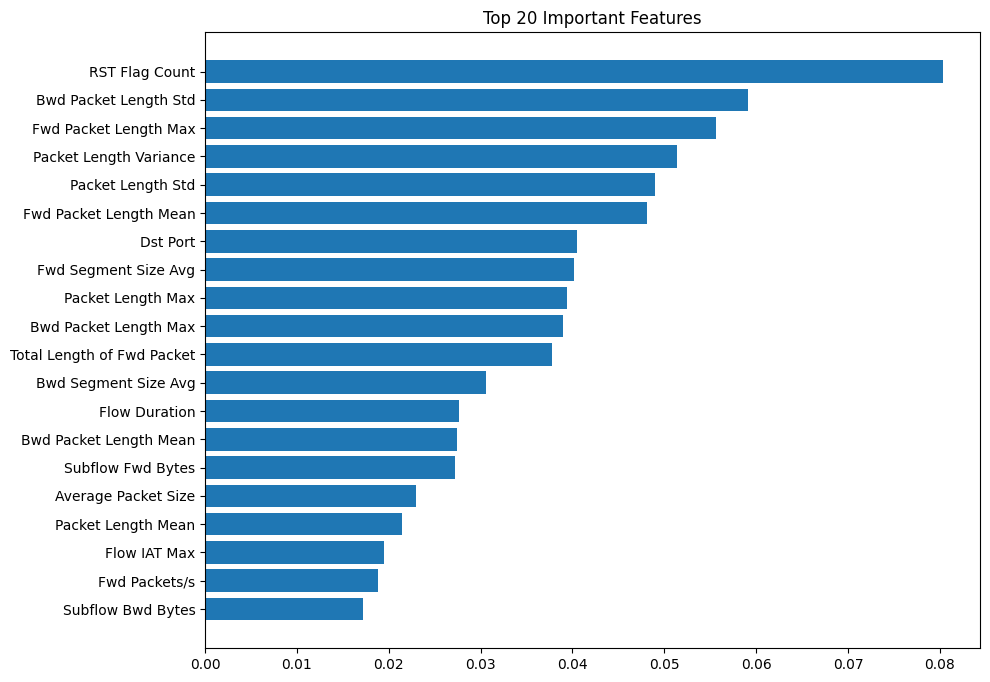

In [27]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [28]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [29]:
top_features = feature_importance.head(20)["Feature"].tolist()

print(top_features)

['RST Flag Count', 'Bwd Packet Length Std', 'Fwd Packet Length Max', 'Packet Length Variance', 'Packet Length Std', 'Fwd Packet Length Mean', 'Dst Port', 'Fwd Segment Size Avg', 'Packet Length Max', 'Bwd Packet Length Max', 'Total Length of Fwd Packet', 'Bwd Segment Size Avg', 'Flow Duration', 'Bwd Packet Length Mean', 'Subflow Fwd Bytes', 'Average Packet Size', 'Packet Length Mean', 'Flow IAT Max', 'Fwd Packets/s', 'Subflow Bwd Bytes']


In [30]:
 اللي اتعلمه من التدريب
X_test_scaled = scaler.transfofrom sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. فلترة البيانات عشان نستخدم الـ 20 ميزة بس
X_selected = X[top_features]

# 2. التقسيم (Train-Test Split) **قبل** أي معالجة لمنع تسريب البيانات
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# 3. توحيد المقاييس (Scaling) بشكل صحيح
scaler = StandardScaler()
# لاحظ: بنعمل fit للـ Scaler على بيانات التدريب فقط!
X_train_scaled = scaler.fit_transform(X_train)
# بيانات الاختبار بيتعملها transform فقط بناءً علىrm(X_test)

print("تم فصل البيانات وعمل Scaling بنجاح وبدون Data Leakage!")
print(f"حجم بيانات التدريب: {X_train_scaled.shape}")
print(f"حجم بيانات الاختبار: {X_test_scaled.shape}")

SyntaxError: invalid syntax (858510986.py, line 1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

# 1. تعريف الموديل 
# استخدام n_jobs=-1 هيستغل كل أنوية المعالج عندك لتسريع التدريب على الـ 1.6 مليون صف
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("جاري تدريب الموديل على البيانات الصحيحة (بدون تسريب)... يرجى الانتظار.")
# 2. تدريب الموديل على بيانات التدريب المعالجة
model.fit(X_train_scaled, y_train)

print("جاري التنبؤ واستخراج النتائج...")
# 3. التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test_scaled)

# 4. حساب المقاييس وطباعتها بأرقام عشرية دقيقة وعدم تقريبها لـ 1.00 بناءً على طلب الدكتور
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print("-" * 55)
print("النتائج الواقعية للموديل (Realistic Performance Metrics)")
print("-" * 55)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print("-" * 55)

print("\nتقرير التصنيف المفصل (Classification Report):")
# استخدام digits=4 لضمان ظهور 4 أرقام عشرية وعدم التقريب التلقائي
print(classification_report(y_test, y_pred, digits=4))

In [ ]:
X_new = X[top_features]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [ ]:
import joblib

joblib.dump(model, "ids_model2.pkl")

In [ ]:
joblib.dump(top_features, "features2.pkl")

In [ ]:
import joblib
import pandas as pd

model = joblib.load("ids_model2.pkl")
features = joblib.load("features2.pkl")

def predict(csv_path):

    df = pd.read_csv(csv_path)

    df = df.reindex(columns=features, fill_value=0)

    prediction = model.predict(df)

    return prediction

# استدعاء الدالة
pred = predict("/kaggle/input/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv")

print(pred)

In [ ]:
print(df.columns.tolist())

In [ ]:
print(features)
print(len(features))

df = pd.read_csv("/kaggle/input/datasets/ahmedhery11/aaaaaa/synthetic_test_data_no_label.csv.xls")

print(df.columns.tolist())
print(len(df.columns))

In [ ]:
print(features == list(df.reindex(columns=features, fill_value=0).columns))

In [ ]:
missing = set(features) - set(df.columns)
extra = set(df.columns) - set(features)

print("Missing:", missing)
print("Extra:", extra)

In [ ]:
print(X_train.describe())

In [ ]:
print(df.describe())

In [ ]:
print(df.shape)

print(df.head())

print(df.describe())

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
import joblib

joblib.dump(model, "random_forest_model.pkl")

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

In [ ]:
sample = X_test.iloc[[0]]

In [ ]:
top_20_features = [
    'RST Flag Count',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Packet Length Std',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Dst Port',
    'Packet Length Max',
    'Bwd Segment Size Avg',
    'Fwd Segment Size Avg',
    'Bwd Packet Length Mean',
    'Total Length of Fwd Packet',
    'Subflow Fwd Bytes',
    'Bwd Packet Length Max',
    'Flow Duration',
    'Packet Length Mean',
    'Fwd Packets/s',
    'Flow IAT Max',
    'Average Packet Size',
    'Subflow Bwd Bytes'
]

In [ ]:
missing = [col for col in top_20_features if col not in df.columns]

print("Missing Features:", missing)

In [ ]:
X = df[top_20_features].copy()
y = df['Label'].copy()

In [ ]:
print(df.columns.tolist())

In [ ]:
y = y.map({
    'BENIGN': 0
}).fillna(1).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_20 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_20.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_20.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "ATTACK"]
))

In [ ]:
import joblib

joblib.dump(model_20, "/kaggle/working/ids_model_20_features.pkl")

In [ ]:
joblib.dump(
    top_20_features,
    "/kaggle/working/ids_model_20_features_names.pkl"
)

In [ ]:
loaded_model = joblib.load(
    "/kaggle/working/ids_model_20_features.pkl"
)

loaded_features = joblib.load(
    "/kaggle/working/ids_model_20_features_names.pkl"
)

print("Number of features:", len(loaded_features))
print(loaded_features)

In [ ]:
prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Prediction:", prediction[0])
print("Actual:", y_test.iloc[0])

In [ ]:
samples = X_test.iloc[:10]

predictions = loaded_model.predict(samples)

results = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Prediction": predictions
})

results["Correct"] = (
    results["Actual"] == results["Prediction"]
)

results

In [ ]:
import joblib
import pandas as pd

model = joblib.load("/kaggle/working/ids_model_20_features.pkl")

In [ ]:
test_data = pd.read_csv("/kaggle/input/datasets/ahmedhery11/hhhhhhhhhhhh/cicids_real_data_20_columns.csv")

In [ ]:
predictions = model.predict(test_data)

In [ ]:
results = test_data.copy()

results["Prediction"] = predictions

results["Prediction"] = results["Prediction"].map({
    0: "BENIGN",
    1: "ATTACK"
})

results

In [ ]:
probabilities = model.predict_proba(test_data)

results["Benign Probability"] = probabilities[:, 0]
results["Attack Probability"] = probabilities[:, 1]

results

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. تجهيز الـ 20 Features
# ==========================================

X_all = df[top_20_features].copy()

# تحويل الـ Label إلى:
# BENIGN = 0
# Attack = 1

y_all = df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

# ==========================================
# 2. خلط الداتا عشوائياً
# ==========================================

random_df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ==========================================
# 3. تقسيم الداتا إلى 5 أجزاء متساوية تقريباً
# ==========================================

parts = np.array_split(random_df, 5)

# ==========================================
# 4. اختبار كل جزء
# ==========================================

accuracies = []

for i, part in enumerate(parts, start=1):

    # Features الخاصة بالجزء الحالي
    X_part = part[top_20_features]

    # Labels الحقيقية
    y_part = part['Label'].apply(
        lambda x: 0 if x == 'BENIGN' else 1
    )

    # Prediction
    y_pred = model_20.predict(X_part)

    # Accuracy
    accuracy = accuracy_score(
        y_part,
        y_pred
    )

    accuracies.append(accuracy)

    print(f"Part {i}")
    print(f"Rows: {len(part):,}")
    print(f"Accuracy: {accuracy:.6f}")
    print(f"Accuracy %: {accuracy * 100:.4f}%")
    print("-" * 40)


# ==========================================
# 5. Accuracy الكلية
# ==========================================

X_all_random = random_df[top_20_features]

y_all_random = random_df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

y_pred_all = model_20.predict(X_all_random)

overall_accuracy = accuracy_score(
    y_all_random,
    y_pred_all
)

print("\n==============================")
print("Overall Accuracy")
print("==============================")
print(f"{overall_accuracy:.6f}")
print(f"{overall_accuracy * 100:.4f}%")

In [ ]:
!pip install scapy

In [ ]:
import pandas as pd
from scapy.all import sniff, IP, TCP, UDP
import warnings
warnings.filterwarnings('ignore')

# 1. قائمة بأسماء الـ 20 Features التي تم الاستقرار عليها وتدريب الموديل بها
EXPECTED_FEATURES = [
    'RST Flag Count',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Packet Length Std',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Dst Port',
    'Packet Length Max',
    'Bwd Segment Size Avg',
    'Fwd Segment Size Avg',
    'Bwd Packet Length Mean',
    'Total Length of Fwd Packet',
    'Subflow Fwd Bytes',
    'Bwd Packet Length Max',
    'Flow Duration',
    'Packet Length Mean',
    'Fwd Packets/s',
    'Flow IAT Max',
    'Average Packet Size',
    'Subflow Bwd Bytes'
]

# 2. دالة معالجة الباقات الحية
def process_live_packet(packet):
    if IP in packet:
        src_ip = packet[IP].src
        dst_ip = packet[IP].dst
        packet_length = len(packet)
        
        # 3. استخراج بعض الخصائص الأساسية من الباقة الحية لغرض الـ Demo
        # نظراً لأن العديد من الخصائص تعتمد على التدفق (Flow) وليس الباقة الواحدة،
        # سنقوم باستخراج ما يمكن من الباقة الحالية وتمرير الباقي كقيم صفرية أو تقريبية.
        live_data = {
            'Dst Port': packet[TCP].dport if TCP in packet else (packet[UDP].dport if UDP in packet else 0),
            'Packet Length Max': packet_length,
            'Packet Length Mean': packet_length,
            'Average Packet Size': packet_length,
            'RST Flag Count': 1 if TCP in packet and packet[TCP].flags == 'R' else 0,
        }
        
        # التأكد من وجود وتعبئة باقي الـ 20 ميزة لتفادي أخطاء الموديل (تعبئة بأصفار للميزات المعقدة)
        for feature in EXPECTED_FEATURES:
            if feature not in live_data:
                live_data[feature] = 0
                
        # 4. تحويل البيانات إلى DataFrame بنفس ترتيب أعمدة التدريب
        df_live = pd.DataFrame([live_data], columns=EXPECTED_FEATURES)
        
        # 5. التنبؤ الحي باستخدام الموديل
        try:
            # تنويه: تأكد أن "model" هو نفس اسم المتغير الخاص بالموديل المدرب في كودك (مثل rf_classifier)
            prediction = model.predict(df_live) 
            
            # 6. طباعة النتائج (بافتراض 1 تعني هجوم و 0 مرور طبيعي)
            if prediction[0] == 1:
                print(f"[!!!] INTRUSION DETECTED | Src: {src_ip} -> Dst: {dst_ip}")
            # تم إيقاف طباعة الـ Normal Traffic لكي لا تمتلئ الشاشة أثناء العرض التقديمي
            # else:
            #    print(f"[+] Normal Traffic | Src: {src_ip} -> Dst: {dst_ip}")
                
        except Exception as e:
            # تجاهل الأخطاء الصامتة لعدم إفساد شكل الـ Demo
            pass

# 7. تشغيل الالتقاط الحي للباقات
print("Starting Live Packet Capture... Press Ctrl+C to stop.")
print("Waiting for network traffic...")

# ابدأ الالتقاط (قم بإزالة علامة # من السطر التالي لتفعيل الالتقاط عند تشغيل الخلية أثناء العرض)
sniff(prn=process_live_packet, store=False, count=0)

In [ ]:
import time

# 1. سحب عينة واحدة (باقة واحدة) من بيانات الاختبار المجهزة
# استخدمنا X_test_scaled اللي جهزناها في الخطوات اللي فاتت
single_packet = X_test_scaled[0].reshape(1, -1)

# 2. خطوة تسخين (Warm-up)
# بنعمل التنبؤ ده في صمت لأن بايثون بياخد وقت أطول في أول عملية، فبنستبعدها عشان القياس يكون دقيق
_ = model.predict(single_packet) 

# 3. قياس زمن الاستجابة الفعلي (Inference Latency)
start_time = time.time()  # تسجيل وقت البداية
prediction = model.predict(single_packet) # تنفيذ التنبؤ الفعلي
end_time = time.time()    # تسجيل وقت النهاية

# 4. حساب الفارق الزمني بالمللي ثانية (ms)
latency_seconds = end_time - start_time
latency_ms = latency_seconds * 1000 

# 5. طباعة النتيجة
print(f"Inference Latency per Flow/Packet: {latency_ms:.4f} ms")